# Parquet Pipeline

In [4]:
%load_ext autoreload
%autoreload 2

import sys, logging, importlib

# Ensure your scripts dir is importable
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")

# 1) Set global logging and quiet noisy libs
logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    force=True,
)
for noisy in ["uproot", "fsspec", "s3fs", "urllib3", "numexpr", "matplotlib"]:
    logging.getLogger(noisy).setLevel(logging.WARNING)

# 2) Turn up only your modules to DEBUG (others inherit WARNING from above)
for name in [
    "convert_all",
    "convert_particles",
    "convert_digihits",
    "convert_tracks",
    "utils",
    "utils.track_utils",
    "utils.driver",
    "utils.path_utils",
]:
    logging.getLogger(name).setLevel(logging.DEBUG)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx
import matplotlib.cm as cm
import h5py
import pyarrow as pa
import pyarrow.parquet as pq
import logging
import awkward as ak
import uproot

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

import pyhepmc as hep
from pyhepmc.io import WriterAscii

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

from pathlib import Path
import logging

# Reuse postprocessing helpers
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")
from convert_particles import build_particles_df_with_parents_and_vertex, write_particles_with_selection
from convert_digihits import process_event_for_digihits, write_digihits_with_selection
from convert_calorimeter import write_calohits_with_selection
from utils.path_utils import get_run_paths, make_dir
from utils.track_utils import load_root_file, load_track_summary, create_particle_barcode_map
from parquet_loading_utils import *

from convert_all import convert_all


### Roadmap

- Load parquet files (tracks, tracker_hits, calo_hits, particles)
- Calculate the run that corresponds to that event
- Load edm4hep file (edm4hep.root), looking just at that event
- Using position and vertex merges, ensure that ALL hits and particles are present in the edm4hep file
- Visualise the event (hits, tracks)
- Deduce the hepmc file and event number from the edm4hep event
- Load the hepmc file and event number in hard scatter AND merged versions
- Ensure that ALL generator particles are present in the hepmc files and vice versa

## Testing parquet outputs

In [5]:
global_event_id = 0
chunk_size = 100
chunk_number = global_event_id // chunk_size
event_range = f"events{chunk_number*chunk_size}-{chunk_number*chunk_size+chunk_size-1}"

In [6]:
event_range

'events0-99'

In [7]:
# Update file paths to point to parquet files
particles_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/parquet/truth/particles/full_pileup.ttbar.v1.truth.particles.{event_range}.parquet"
digihits_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/parquet/reco/tracker_hits/full_pileup.ttbar.v1.reco.tracker_hits.{event_range}.parquet"
tracks_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/parquet/reco/tracks/full_pileup.ttbar.v1.reco.tracks.{event_range}.parquet"
calohits_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/parquet/reco/calo_hits/full_pileup.ttbar.v1.reco.calo_hits.{event_range}.parquet"

In [10]:
# Test loading a single event from parquet with improved functions
parquet_particles_df = load_all_particles_parquet(particles_file, event_id=global_event_id)
parquet_trackerhits_df = load_all_digihits_parquet(digihits_file, event_id=global_event_id)
parquet_tracks_df, parquet_track_hits_df = load_all_tracks_parquet(tracks_file, event_id=global_event_id)
parquet_calohits_df, parquet_calocontribs_df = load_all_calohits_parquet(calohits_file, event_id=global_event_id)

print(f"Loaded event {global_event_id}:")
print(f"  Particles: {len(parquet_particles_df)} rows")
print(f"  Digihits: {len(parquet_trackerhits_df)} rows")
print(f"  Tracks: {len(parquet_tracks_df)} rows")
print(f"  Calohits: {len(parquet_calohits_df)} rows")
print(f"  Calohit contributions: {len(parquet_calocontribs_df)} rows")

Loaded event 0:
  Particles: 152803 rows
  Digihits: 214203 rows
  Tracks: 1395 rows
  Calohits: 669672 rows
  Calohit contributions: 894708 rows


In [15]:
parquet_particles_df.dtypes

event_id           uint32
particle_id        uint64
pdg_id              int64
mass              float32
energy            float32
charge            float32
vx                float32
vy                float32
vz                float32
time              float32
px                float32
py                float32
pz                float32
perigee_d0        float32
perigee_z0        float32
vertex_primary     uint16
parent_id           int64
primary              bool
dtype: object

In [11]:
parquet_particles_df

,event_id,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,perigee_d0,perigee_z0,vertex_primary,parent_id,primary
0,0,175,213,0.843490,2.868551,1.0,-0.011325,-0.007458,116.524422,-0.008199,-2.640321,0.619228,0.402955,0.009847,116.523033,1,7,True
1,0,176,111,0.134980,5.070231,0.0,-0.011325,-0.007458,116.524422,-0.008199,-5.051859,0.380967,-0.150373,0.008288,116.524734,1,7,True
2,0,177,221,0.547850,4.257434,0.0,-0.011325,-0.007458,116.524422,-0.008199,-4.040839,0.580850,-1.076958,0.008993,116.527100,1,7,True
3,0,178,-211,0.139570,0.521287,-1.0,-0.011325,-0.007458,116.524422,-0.008199,-0.442601,0.233980,0.040229,0.011886,116.523895,1,7,True
4,0,179,111,0.134980,2.191711,0.0,-0.011325,-0.007458,116.524422,-0.008199,-2.166845,0.055207,0.295143,0.007744,116.522903,1,7,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152798,0,188038,11,0.000511,0.439283,-1.0,-1265.676636,-86.509972,631.888550,4.559305,-0.405805,-0.028531,0.165765,NaN,NaN,1,188036,False
152799,0,188039,-11,0.000511,0.468531,1.0,-1265.676636,-86.509972,631.888550,4.559305,-0.433282,-0.028871,0.175937,NaN,NaN,1,188036,False
152800,0,188040,11,0.000511,0.101399,-1.0,-1272.643799,-86.827286,634.885986,4.584627,-0.092992,-0.005166,0.040091,NaN,NaN,1,188039,False
152801,0,188041,-11,0.000511,0.222422,1.0,-1272.643799,-86.827286,634.885986,4.584627,-0.204042,-0.008541,0.088121,NaN,NaN,1,188039,False


In [12]:
parquet_trackerhits_df.dtypes

event_id        uint32
x              float32
y              float32
z              float32
true_x         float32
true_y         float32
true_z         float32
time           float32
particle_id     uint64
detector         uint8
volume_id        uint8
layer_id        uint16
surface_id      uint32
dtype: object

In [13]:
parquet_trackerhits_df

,event_id,x,y,z,true_x,true_y,true_z,time,particle_id,detector,volume_id,layer_id,surface_id
0,0,58.325001,-4.625000,-1515.599976,58.325787,-4.645725,-1515.599976,4.356745,54948,0,16,4,1
1,0,47.525002,6.975000,-1515.599976,47.545902,6.992651,-1515.599976,4.361829,19301,0,16,4,1
2,0,59.625000,-2.375000,-1515.599976,59.605087,-2.367985,-1515.599976,4.518640,53403,0,16,4,1
3,0,73.115204,-5.175000,-1515.599976,73.102837,-5.180788,-1515.599976,4.519290,64757,0,16,4,1
4,0,77.925003,-5.325001,-1515.599976,77.925995,-5.315741,-1515.599976,4.538421,53070,0,16,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
214198,0,354.757965,924.062622,3009.500000,342.797424,893.461487,3009.500000,20.392855,176796,8,30,12,192
214199,0,340.263855,929.729370,3009.500000,338.543396,925.254883,3009.375000,21.113811,141840,8,30,12,192
214200,0,337.295197,930.890076,3009.500000,333.723236,921.674255,3009.500000,21.128506,141834,8,30,12,192
214201,0,359.822174,922.082642,3009.500000,369.436005,946.692871,3009.500000,34.703232,133093,8,30,12,192


In [16]:
parquet_tracks_df

,event_id,d0,z0,phi,theta,qop,majority_particle_id,track_id
0,0,0.731816,45.951920,-3.004526,0.108162,0.119804,60399,0
1,0,-0.050671,31.447231,3.117979,3.041248,-0.101316,48152,1
2,0,0.164032,-23.924641,-3.140298,0.103628,-0.099680,59715,2
3,0,0.155390,-91.208740,-3.054169,2.968126,-0.146114,64539,3
4,0,0.061489,39.228699,-2.987440,0.707252,0.846438,39378,4
...,...,...,...,...,...,...,...,...
1390,0,-0.088596,22.759666,3.121675,2.180644,0.757621,10553,1390
1391,0,0.174440,-131.498413,3.087043,0.404091,0.410909,76559,1391
1392,0,0.013738,53.940823,2.983989,2.010878,-0.717632,26583,1392
1393,0,-0.118122,-45.397354,-3.094629,0.906911,0.834673,37337,1393


In [17]:
parquet_track_hits_df

,event_id,hit_ids,track_id
0,0,"[167730, 163963, 83395, 80295, 77246, 77273, 7...",0
1,0,"[84897, 89138, 2205, 5327, 8359, 9538, 12554, ...",1
2,0,"[167784, 163989, 83393, 80291, 77243, 72697, 6...",2
3,0,"[86715, 90717, 92886, 92849, 96341, 99510, 114...",3
4,0,"[203920, 186616, 186612, 146928, 137701, 12510...",4
...,...,...,...
1390,0,"[197033, 197031, 186485, 186482, 186636, 18663...",1390
1391,0,"[209116, 206236, 206246, 109173, 59084, 49092,...",1391
1392,0,"[198265, 198260, 187588, 187583, 147369, 13800...",1392
1393,0,"[186565, 146920, 137679, 125056, 109105, 10996...",1393


In [18]:
parquet_calohits_df

,event_id,cell_index,detector,total_energy,x,y,z
0,0,0,9,0.000816,202.366150,296.128510,-3308.449951
1,0,1,10,0.000229,142.800003,-1333.199951,1071.000000
2,0,2,11,0.000639,-76.500000,-678.888977,3379.149902
3,0,3,10,0.000276,-66.300003,-1287.750000,1621.800049
4,0,4,11,0.000209,444.121674,-128.759232,3374.100098
...,...,...,...,...,...,...,...
669667,0,669667,11,0.000924,270.884796,-234.822357,3278.149902
669668,0,669668,12,0.001299,-426.024139,-341.171326,-3800.500000
669669,0,669669,11,0.000132,-117.300003,-699.288940,3212.500000
669670,0,669670,11,0.000194,-581.021851,436.772064,3348.850098


## Validation Checks

In [19]:
# Add number of hits to particles_df
num_tracker_hits = parquet_trackerhits_df.groupby("particle_id").size()
parquet_particles_df["num_tracker_hits"] = parquet_particles_df.particle_id.map(num_tracker_hits)
parquet_tracks_df["num_particle_hits"] = parquet_tracks_df.merge(parquet_particles_df[["particle_id", "num_tracker_hits"]], left_on="majority_particle_id", right_on="particle_id", how="left").num_tracker_hits
parquet_tracks_df["num_track_hits"] = parquet_track_hits_df.hit_ids.apply(len)
parquet_tracks_df["hit_ids"] = parquet_track_hits_df.hit_ids

def get_num_shared_hits(track_row):
    track_hit_ids = track_row.hit_ids
    particle_hit_ids = parquet_trackerhits_df[parquet_trackerhits_df.particle_id == track_row.majority_particle_id].index.tolist()
    return len(set(track_hit_ids) & set(particle_hit_ids))

parquet_tracks_df["num_shared_hits"] = parquet_tracks_df.apply(get_num_shared_hits, axis=1)

In [20]:
parquet_tracks_df["efficiency"] = parquet_tracks_df["num_shared_hits"] / parquet_tracks_df["num_particle_hits"]
parquet_tracks_df["purity"] = parquet_tracks_df["num_shared_hits"] / parquet_tracks_df["num_track_hits"]

In [21]:
print(f"Efficiency: {parquet_tracks_df.efficiency.mean()}, Purity: {parquet_tracks_df.purity.mean()}")

Efficiency: 0.8518537773987572, Purity: 0.8950173671410231


Text(0.5, 1.0, 'Track 0: Track hits vs True particle hits, track ID: 0')

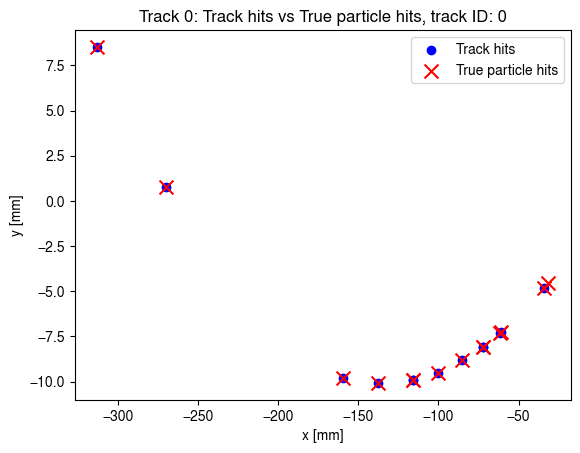

In [22]:
track_index = 0
track_hit_ids = parquet_track_hits_df.iloc[track_index].hit_ids

plt.scatter(parquet_trackerhits_df.x.iloc[track_hit_ids], parquet_trackerhits_df.y.iloc[track_hit_ids], marker='o', color="b", label="Track hits")

# Get the majority particle id for the track
track_majority_particle_id = parquet_tracks_df.iloc[track_index]['majority_particle_id']

# Get the hit ids for the majority particle id
majority_particle_hit_ids = parquet_trackerhits_df[parquet_trackerhits_df.particle_id == track_majority_particle_id].index.tolist()
plt.scatter(parquet_trackerhits_df.x.iloc[majority_particle_hit_ids], parquet_trackerhits_df.y.iloc[majority_particle_hit_ids], marker='x', color="red", s=100, label="True particle hits")

# Add legend
plt.legend()
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title(f"Track {track_index}: Track hits vs True particle hits, track ID: {parquet_tracks_df.track_id.iloc[track_index]}")

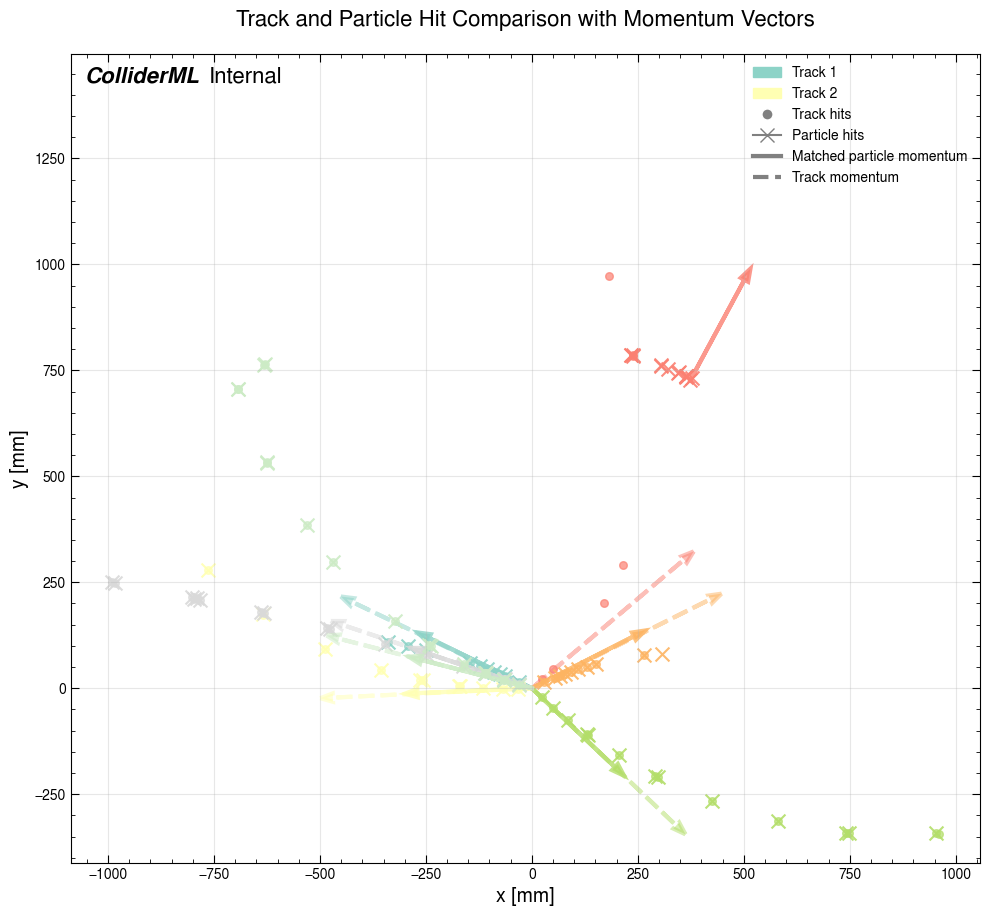

In [23]:
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 10))
num_tracks_to_sample = 7

# Randomly sample track indices
track_indices = np.random.choice(len(parquet_tracks_df), size=min(num_tracks_to_sample, len(parquet_tracks_df)), replace=False)

# Use a pleasant colormap with more colors
cmap = plt.cm.Set3  # Set3 provides 12 distinct, pleasant colors
colors = [cmap(i / num_tracks_to_sample) for i in range(num_tracks_to_sample)]

legend_elements = []

for idx, track_idx in enumerate(track_indices):
    # Plot the track hits
    track_hit_ids = parquet_track_hits_df.iloc[track_idx].hit_ids
    track_scatter = plt.scatter(parquet_trackerhits_df.x.iloc[track_hit_ids], parquet_trackerhits_df.y.iloc[track_hit_ids], 
                               marker='o', color=colors[idx], s=30, alpha=0.7, 
                               label=f'Track {idx+1} hits')

    # Get the majority particle id for the track
    majority_particle_id = parquet_tracks_df.iloc[track_idx]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = parquet_trackerhits_df[parquet_trackerhits_df.particle_id == majority_particle_id].index.tolist()
    particle_scatter = plt.scatter(parquet_trackerhits_df.x.iloc[majority_particle_hit_ids], parquet_trackerhits_df.y.iloc[majority_particle_hit_ids], 
                                  marker='x', color=colors[idx], s=100, alpha=0.9,
                                  label=f'Particle {idx+1} hits')
    
    # Plot the phi vector of the particle as an arrow (solid arrow)
    particle_entry = parquet_particles_df[parquet_particles_df['particle_id'] == majority_particle_id].iloc[0]
    normalised_momentum_vector = particle_entry[['px', 'py']].values / np.linalg.norm(particle_entry[['px', 'py']].values)*300
    particle_arrow = plt.arrow(particle_entry['vx'], particle_entry['vy'], normalised_momentum_vector[0], normalised_momentum_vector[1], 
              color=colors[idx], head_width=20, head_length=30, length_includes_head=True, alpha=0.8, linewidth=3)
    phi = np.arctan2(particle_entry['py'], particle_entry['px'])

    # Plot the phi vector of the track (dashed arrow)
    track_entry = parquet_tracks_df.iloc[track_idx]
    phi = track_entry['phi']
    
    # Convert phi to px, py components (assuming unit momentum for visualization)
    track_px = np.cos(phi) * 500  # scale for visualization
    track_py = np.sin(phi) * 500
    
    # Plot from origin (assuming tracks start from origin for visualization)
    track_arrow = plt.arrow(0, 0, track_px, track_py, color=colors[idx], head_width=20, head_length=30, 
              length_includes_head=True, alpha=0.5, linewidth=3, linestyle='--')

# Create custom legend elements
legend_elements = [
    mpatches.Patch(color=colors[0], label='Track 1'),
    mpatches.Patch(color=colors[1], label='Track 2'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Track hits'),
    plt.Line2D([0], [0], marker='x', color='gray', markerfacecolor='gray', markersize=10, label='Particle hits'),
    plt.Line2D([0], [0], color='gray', linewidth=3, label='Matched particle momentum'),
    plt.Line2D([0], [0], color='gray', linewidth=3, linestyle='--', label='Track momentum')
]

plt.legend(handles=legend_elements, loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.xlabel('x [mm]', fontsize=14)
plt.ylabel('y [mm]', fontsize=14)
plt.title('Track and Particle Hit Comparison with Momentum Vectors', fontsize=16, pad=20)

# Add ATLAS label
atl.atlasify("Internal")

plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', 'box')
plt.tight_layout()
plt.show()


## EDM4HEP Version

In [24]:
run_size = 128
run_id = global_event_id // run_size
local_event = global_event_id % run_size

In [25]:
edm4hep_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/{run_id}/edm4hep.root"
edm4hep_event = EDM4hepEventBatch(str(edm4hep_file), events=(local_event, local_event+1), condense_calo=False)

2025-11-26 04:24:43,822 - DEBUG - pyedm4hep.event_batch - EDM4hepEventBatch init: file=/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/0/edm4hep.root, events=(0, 1), full_load=False, condense_calo=False


In [26]:
edm4hep_trackerhits_df = edm4hep_event.get_tracker_hits_df()
edm4hep_calohits_df = edm4hep_event.get_calo_hits_df()
edm4hep_contributions_df = edm4hep_event.get_calo_contributions_df()
edm4hep_particles_df = edm4hep_event.get_particles_df()

2025-11-26 04:24:45,136 - DEBUG - pyedm4hep.event_batch - _load_tracker_hits: start=0, stop=1
2025-11-26 04:24:45,138 - DEBUG - asyncio - Using selector: EpollSelector
2025-11-26 04:24:45,346 - DEBUG - pyedm4hep.event_batch - tracker PixelBarrelReadout: rows=43525 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-11-26 04:24:45,489 - DEBUG - pyedm4hep.event_batch - tracker PixelEndcapReadout: rows=40711 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-11-26 04:24:45,602 - DEBUG - pyedm4hep.event_batch - tracker ShortStripBarrelReadout: rows=46125 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-11-26 04:24:45,697 - DEBUG - pyedm4hep.event_batch - tracker ShortStripEndcapReadout: rows=40889 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-11-26 04:24:45,896 - DEBUG - pyedm4hep.event_batch - tracker LongStripBarrelReadout: rows=20187 cols=['event_id', 'subentry', 'ce

In [27]:
edm4hep_particles_df

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
0,0,0,2212,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,...,6999.999937,0,0,0.000000,7000.000000,6999.061730,0,False,0,0
1,0,1,1,0,-0.333333,-0.008199,0.000000,-0.011325,-0.007458,116.524419,...,1415.282631,0,1,0.013560,1415.282631,1415.282631,1,False,0,0
2,0,2,2203,0,1.333333,-0.008199,0.771330,-0.011325,-0.007458,116.524419,...,5584.717325,1,2,0.013560,5584.717379,5583.946049,2,False,0,0
3,0,3,2212,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,...,-6999.999937,2,2,0.000000,7000.000000,6999.061730,3,False,0,0
4,0,4,2,0,0.666667,-0.008199,0.000000,-0.011325,-0.007458,116.524419,...,-2016.335058,2,3,0.013560,2016.335058,2016.335058,4,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188038,0,188038,11,1157627904,-1.000000,4.559305,0.000511,-1265.676608,-86.509970,631.888553,...,0.165765,329019,329020,1268.629675,0.439283,0.438772,188038,True,0,95
188039,0,188039,-11,1157627904,1.000000,4.559305,0.000511,-1265.676608,-86.509970,631.888553,...,0.175937,329020,329021,1268.629675,0.468531,0.468020,188039,True,0,69
188040,0,188040,11,1426063360,-1.000000,4.584627,0.000511,-1272.643806,-86.827286,634.886014,...,0.040091,329021,329022,1275.602303,0.101399,0.100888,188040,True,0,64
188041,0,188041,-11,1426063360,1.000000,4.584627,0.000511,-1272.643806,-86.827286,634.886014,...,0.088121,329022,329023,1275.602303,0.222422,0.221911,188041,True,0,86


In [28]:
edm4hep_trackerhits_df

,event_id,subentry,cellID,time,x,y,z,detector,particle_id,r,R,phi,theta,eta
0,0,0,6931398611241990,0.611640,0.668716,-32.106328,-89.063451,PixelBarrelReadout,75699,32.113292,94.676089,-1.549971,2.795536,-1.744249
1,0,1,71266396637698070,1.182943,5.013834,-67.582397,-255.976585,PixelBarrelReadout,75699,67.768126,264.795263,-1.496744,2.882787,-2.039220
2,0,2,68098652098468118,1.213924,5.337656,-69.484042,-265.025765,PixelBarrelReadout,75699,69.688756,274.034996,-1.494128,2.884463,-2.045789
3,0,3,71424490088704038,1.925980,15.964708,-112.813853,-473.046001,PixelBarrelReadout,75699,113.937866,486.574102,-1.430216,2.905235,-2.130884
4,0,4,70122539472718854,0.693725,0.784387,-32.092381,-114.241075,PixelBarrelReadout,75695,32.101965,118.665746,-1.546360,2.867655,-1.981721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214202,0,22765,16527035294030,11.609076,-898.168560,278.110867,2620.616385,LongStripEndcapReadout,187893,940.240616,2784.184378,2.841313,0.344480,1.748907
214203,0,22766,1095217803582,11.380589,-1001.428406,169.845890,2259.375000,LongStripEndcapReadout,187914,1015.729531,2477.192336,2.973588,0.422490,1.539706
214204,0,22767,863289540958,11.748932,-488.012455,782.169450,3020.455139,LongStripEndcapReadout,187925,921.924729,3158.020654,2.128620,0.296245,1.902363
214205,0,22768,1086626795566,6.548157,-492.026756,704.922058,1874.557815,LongStripEndcapReadout,187927,859.654254,2062.273609,2.180170,0.429975,1.521601


In [29]:
parquet_trackerhits_df

,event_id,x,y,z,true_x,true_y,true_z,time,particle_id,detector,volume_id,layer_id,surface_id
0,0,58.325001,-4.625000,-1515.599976,58.325787,-4.645725,-1515.599976,4.356745,54948,0,16,4,1
1,0,47.525002,6.975000,-1515.599976,47.545902,6.992651,-1515.599976,4.361829,19301,0,16,4,1
2,0,59.625000,-2.375000,-1515.599976,59.605087,-2.367985,-1515.599976,4.518640,53403,0,16,4,1
3,0,73.115204,-5.175000,-1515.599976,73.102837,-5.180788,-1515.599976,4.519290,64757,0,16,4,1
4,0,77.925003,-5.325001,-1515.599976,77.925995,-5.315741,-1515.599976,4.538421,53070,0,16,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
214198,0,354.757965,924.062622,3009.500000,342.797424,893.461487,3009.500000,20.392855,176796,8,30,12,192
214199,0,340.263855,929.729370,3009.500000,338.543396,925.254883,3009.375000,21.113811,141840,8,30,12,192
214200,0,337.295197,930.890076,3009.500000,333.723236,921.674255,3009.500000,21.128506,141834,8,30,12,192
214201,0,359.822174,922.082642,3009.500000,369.436005,946.692871,3009.500000,34.703232,133093,8,30,12,192


In [30]:
df1 = edm4hep_trackerhits_df[["x", "y", "z"]].astype(np.float32)
df2 = parquet_trackerhits_df[["true_x", "true_y", "true_z"]].astype(np.float32)
df1.columns = ["x", "y", "z"]
df2.columns = ["x", "y", "z"]
merged_hits = df1.merge(df2, on=["x", "y", "z"], how="inner")
print(f"{len(merged_hits)} out of {len(edm4hep_trackerhits_df)} hits match within tolerance.")

214205 out of 214207 hits match within tolerance.


In [31]:
# Test vx, vy, vz (_x and _y are the same)
merged_particles = parquet_particles_df.merge(edm4hep_particles_df, on="particle_id", how="inner", suffixes=("_parquet", "_edm4hep"))
df1 = merged_particles[["vx_parquet", "vy_parquet", "vz_parquet", "px_parquet", "py_parquet", "pz_parquet"]].astype(np.float32)
df2 = merged_particles[["vx_edm4hep", "vy_edm4hep", "vz_edm4hep", "px_edm4hep", "py_edm4hep", "pz_edm4hep"]].astype(np.float32)
df1.columns = ["vx", "vy", "vz", "px", "py", "pz"]
df2.columns = ["vx", "vy", "vz", "px", "py", "pz"]
comparison = (df1 - df2).abs() < 1e-4  # adjust tolerance if needed
comparison_all = comparison.all(axis=1)
print(f"{comparison_all.sum()} out of {len(comparison_all)} particles match within tolerance.")

# Optionally, show where mismatches occur
if not comparison_all.all():
    mismatches = pd.concat([df1[~comparison_all], df2[~comparison_all]], axis=1, keys=["edm4hep", "parquet"])
    print("Mismatching particles:")
    delta = merged_particles[f"{col}_parquet"] - merged_particles[f"{col}_edm4hep"]
    print(f"Max delta: {delta.abs().max()}")
    print("\n")

152803 out of 152803 particles match within tolerance.


In [32]:
merged_particles.columns

Index(['event_id_parquet', 'particle_id', 'pdg_id', 'mass_parquet',
       'energy_parquet', 'charge_parquet', 'vx_parquet', 'vy_parquet',
       'vz_parquet', 'time_parquet', 'px_parquet', 'py_parquet', 'pz_parquet',
       'perigee_d0', 'perigee_z0', 'vertex_primary', 'parent_id', 'primary',
       'num_tracker_hits_parquet', 'event_id_edm4hep', 'subentry', 'PDG',
       'simulatorStatus', 'charge_edm4hep', 'time_edm4hep', 'mass_edm4hep',
       'vx_edm4hep', 'vy_edm4hep', 'vz_edm4hep', 'px_edm4hep', 'py_edm4hep',
       'pz_edm4hep', 'parents_begin', 'parents_end', 'vr', 'energy_edm4hep',
       'kinetic_energy', 'created_in_simulation', 'num_tracker_hits_edm4hep',
       'num_calo_hits'],
      dtype='object')

In [33]:
# Check that all generator particles are present from the edm4hep collection
edm4hep_generator_particles = edm4hep_particles_df[edm4hep_particles_df.created_in_simulation == False]
parquet_generator_particles = merged_particles[merged_particles.created_in_simulation == False]
print(f"Number of generator particles in edm4hep: {len(edm4hep_generator_particles)}")
print(f"Number of generator particles in parquet: {len(parquet_generator_particles)}")

edm4hep_particles_with_hits = edm4hep_particles_df[(edm4hep_particles_df.num_tracker_hits > 0) | (edm4hep_particles_df.num_calo_hits > 0)]
parquet_particles_with_hits = merged_particles[(merged_particles.num_tracker_hits_edm4hep > 0) | (merged_particles.num_calo_hits > 0)]
print(f"Number of particles with hits in edm4hep: {len(edm4hep_particles_with_hits)}")
print(f"Number of particles with hits in parquet: {len(parquet_particles_with_hits)}")


Number of generator particles in edm4hep: 75806
Number of generator particles in parquet: 40566
Number of particles with hits in edm4hep: 116561
Number of particles with hits in parquet: 116561


In [35]:
# Cast all x,y,z to float32
parquet_calohits_df = parquet_calohits_df.astype({"x": np.float32, "y": np.float32, "z": np.float32})
edm4hep_calohits_df = edm4hep_calohits_df.astype({"x": np.float32, "y": np.float32, "z": np.float32})
merged_calo = parquet_calohits_df.merge(edm4hep_calohits_df, on=["x", "y", "z"], how="inner")
print(f"Parqet has {len(parquet_calohits_df)} calo hits, EDM4hep has {len(edm4hep_calohits_df)} calo hits.")
print(f"{len(merged_calo)} out of {len(edm4hep_calohits_df)} calo hits match within tolerance.")

Parqet has 669672 calo hits, EDM4hep has 1100578 calo hits.
669672 out of 1100578 calo hits match within tolerance.


## HepMC Version

#### Hard Scatter

In [36]:
hepmc_hs_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/{run_id}/events.hepmc"

In [37]:
root_file = uproot.open(edm4hep_file)["events"]

In [38]:
hepmc_event_number = root_file["EventHeader/EventHeader.eventNumber"].arrays()[local_event]["EventHeader.eventNumber"].tolist()[0]
print(f"HepMC event number: {hepmc_event_number}")

HepMC event number: 0


In [39]:
hepmc_event_number

0

In [40]:
with hep.open(str(hepmc_hs_file)) as f:
    for i, evt in enumerate(f):
        if evt.event_number == hepmc_event_number:
            hepmc_hs_event = evt
            break

In [41]:
hepmc_hs_momentum_df = pd.DataFrame(
    {
        "px": hepmc_hs_event.numpy.particles.px,
        "py": hepmc_hs_event.numpy.particles.py,
        "pz": hepmc_hs_event.numpy.particles.pz
    }
).astype(np.float32)
hepmc_hs_momentum_df

,px,py,pz
0,0.000000e+00,0.000000e+00,7000.000000
1,2.465190e-32,-2.465190e-32,1415.282593
2,0.000000e+00,0.000000e+00,5584.717285
3,0.000000e+00,0.000000e+00,-7000.000000
4,-2.465190e-32,7.395571e-32,-2016.335083
...,...,...,...
851,-2.084115e-01,-7.941593e-01,-13.774734
852,-3.555563e-01,-1.008194e+00,-20.426935
853,-8.245896e-01,-8.948312e-01,-17.900682
854,-8.509279e+00,-2.031254e+01,-339.244263


In [42]:
merged_particles.columns

Index(['event_id_parquet', 'particle_id', 'pdg_id', 'mass_parquet',
       'energy_parquet', 'charge_parquet', 'vx_parquet', 'vy_parquet',
       'vz_parquet', 'time_parquet', 'px_parquet', 'py_parquet', 'pz_parquet',
       'perigee_d0', 'perigee_z0', 'vertex_primary', 'parent_id', 'primary',
       'num_tracker_hits_parquet', 'event_id_edm4hep', 'subentry', 'PDG',
       'simulatorStatus', 'charge_edm4hep', 'time_edm4hep', 'mass_edm4hep',
       'vx_edm4hep', 'vy_edm4hep', 'vz_edm4hep', 'px_edm4hep', 'py_edm4hep',
       'pz_edm4hep', 'parents_begin', 'parents_end', 'vr', 'energy_edm4hep',
       'kinetic_energy', 'created_in_simulation', 'num_tracker_hits_edm4hep',
       'num_calo_hits'],
      dtype='object')

In [49]:
hs_merged_particles = merged_particles[merged_particles.vertex_primary == 1]
hs_generator_particles = hs_merged_particles[hs_merged_particles.primary].astype({"px_parquet": np.float32, "py_parquet": np.float32, "pz_parquet": np.float32})

In [50]:
hepmc_hs_momentum_df.drop_duplicates(subset=["px", "py", "pz"], inplace=True)
hs_generator_particles.drop_duplicates(subset=["px_parquet", "py_parquet", "pz_parquet"], inplace=True)


In [51]:
print(f"There are {len(hepmc_hs_momentum_df)} particles in the HEPMC hard scatter event")
print(f"There are {len(hs_generator_particles)} generator particles in the EDM4hep hard scatter event")

# Exact float32 precision overlap
merged_hepmc_parquet_hs = hepmc_hs_momentum_df.merge(
    hs_generator_particles, 
    left_on=["px", "py", "pz"], 
    right_on=["px_parquet", "py_parquet", "pz_parquet"], 
    how="inner"
)
print(f"There are {len(merged_hepmc_parquet_hs)} particles in the HEPMC hard scatter event that are PERFECTLY (float32 precision) in the parquet hard scatter event")

# Now overlap within 0.1% and 1% relative difference
def get_presence_count(hs_gen_df, hepmc_df, threshold):
    hs_px = hs_gen_df["px_parquet"].values
    hs_py = hs_gen_df["py_parquet"].values
    hs_pz = hs_gen_df["pz_parquet"].values
    hepmc_px = hepmc_df["px"].values
    hepmc_py = hepmc_df["py"].values
    hepmc_pz = hepmc_df["pz"].values

    count = 0
    for i in range(len(hs_gen_df)):
        # Compute relative differences
        px_diff = np.abs(hs_px[i] - hepmc_px) / np.clip(np.abs(hs_px[i]), 1e-10, None)
        py_diff = np.abs(hs_py[i] - hepmc_py) / np.clip(np.abs(hs_py[i]), 1e-10, None)
        pz_diff = np.abs(hs_pz[i] - hepmc_pz) / np.clip(np.abs(hs_pz[i]), 1e-10, None)
        mean_diff = (px_diff + py_diff + pz_diff) / 3.0
        # If *any* of the differences for this particle is below threshold, count as present
        if np.any(mean_diff < threshold):
            count += 1
    return count

count_0p1 = get_presence_count(hs_generator_particles, hepmc_hs_momentum_df, 0.001)
count_1 = get_presence_count(hs_generator_particles, hepmc_hs_momentum_df, 0.01)

print(f"There are {count_0p1} generator particles in the HEPMC hard scatter event that match to a HEPMC particle within 0.1% relative mean (px/py/pz) difference")
print(f"There are {count_1} generator particles in the HEPMC hard scatter event that match to a HEPMC particle within 1% relative mean (px/py/pz) difference")



There are 715 particles in the HEPMC hard scatter event
There are 374 generator particles in the EDM4hep hard scatter event
There are 228 particles in the HEPMC hard scatter event that are PERFECTLY (float32 precision) in the parquet hard scatter event
There are 372 generator particles in the HEPMC hard scatter event that match to a HEPMC particle within 0.1% relative mean (px/py/pz) difference
There are 372 generator particles in the HEPMC hard scatter event that match to a HEPMC particle within 1% relative mean (px/py/pz) difference


In [52]:
# Get those hs_generator_particles that are not in the merged_hepmc_parquet_hs
missing_particles = hs_generator_particles[~hs_generator_particles.particle_id.isin(merged_hepmc_parquet_hs.particle_id)]
missing_particles


,event_id_parquet,particle_id,pdg_id,mass_parquet,energy_parquet,charge_parquet,vx_parquet,vy_parquet,vz_parquet,time_parquet,...,py_edm4hep,pz_edm4hep,parents_begin,parents_end,vr,energy_edm4hep,kinetic_energy,created_in_simulation,num_tracker_hits_edm4hep,num_calo_hits
63,0,286,211,0.13957,1.904712,1.0,-0.011325,-0.007458,116.524422,-0.008199,...,0.687194,0.015400,1452,1453,0.013560,1.904712,1.765142,False,13,283
64,0,287,111,0.13498,0.963842,0.0,-0.011325,-0.007458,116.524422,-0.008199,...,-0.067966,0.387557,1453,1454,0.013560,0.963842,0.828862,False,0,51
65,0,288,111,0.13498,2.747943,0.0,-0.011326,-0.007458,116.524422,-0.008199,...,0.462865,-0.641503,1454,1455,0.013561,2.747943,2.612963,False,0,0
66,0,289,111,0.13498,0.594501,0.0,-0.011326,-0.007458,116.524422,-0.008199,...,0.020610,-0.164304,1455,1456,0.013561,0.594501,0.459521,False,0,0
67,0,290,111,0.13498,0.914999,0.0,-0.011326,-0.007458,116.524422,-0.008199,...,0.097376,-0.271154,1456,1457,0.013561,0.914999,0.780019,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,0,847,-211,0.13957,3.885960,-1.0,-0.011325,-0.007458,116.524422,-0.008199,...,-0.111980,-3.751238,2628,2629,0.013560,3.885960,3.746390,False,7,0
373,0,848,211,0.13957,1.120649,1.0,-0.011325,-0.007458,116.524422,-0.008199,...,0.138622,-1.029721,2629,2630,0.013560,1.120649,0.981079,False,4,107
374,0,849,111,0.13498,2.295012,0.0,-0.011325,-0.007458,116.524422,-0.008199,...,-0.209048,-2.281129,2630,2631,0.013560,2.295012,2.160032,False,0,0
376,0,851,111,0.13498,13.799846,0.0,-0.011325,-0.007458,116.524422,-0.008199,...,-0.794159,-13.774737,2632,2633,0.013560,13.799846,13.664866,False,0,0


In [53]:
for i in merged_particles.vertex_primary.unique():
    hs_merged_particles = merged_particles[merged_particles.vertex_primary == i]
    hs_generator_particles = hs_merged_particles[hs_merged_particles.created_in_simulation == False].astype({"px_parquet": np.float32, "py_parquet": np.float32, "pz_parquet": np.float32})
    print(f"There are {len(hs_generator_particles)} generator particles in the HEPMC hard scatter event for vertex primary {i}")
    merged_hepmc_parquet_hs = hepmc_hs_momentum_df.merge(hs_generator_particles, left_on=["px", "py", "pz"], right_on=["px_parquet", "py_parquet", "pz_parquet"], how="inner")
    print(f"There are {len(merged_hepmc_parquet_hs)} particles in the HEPMC hard scatter event that are also in the parquet hard scatter event for vertex primary {i}")
    

There are 381 generator particles in the HEPMC hard scatter event for vertex primary 1
There are 229 particles in the HEPMC hard scatter event that are also in the parquet hard scatter event for vertex primary 1
There are 511 generator particles in the HEPMC hard scatter event for vertex primary 2
There are 0 particles in the HEPMC hard scatter event that are also in the parquet hard scatter event for vertex primary 2
There are 225 generator particles in the HEPMC hard scatter event for vertex primary 3
There are 0 particles in the HEPMC hard scatter event that are also in the parquet hard scatter event for vertex primary 3
There are 268 generator particles in the HEPMC hard scatter event for vertex primary 4
There are 0 particles in the HEPMC hard scatter event that are also in the parquet hard scatter event for vertex primary 4
There are 267 generator particles in the HEPMC hard scatter event for vertex primary 5
There are 0 particles in the HEPMC hard scatter event that are also in 

In [62]:
edm4hep_generator_particles.astype({"px": np.float32, "py": np.float32, "pz": np.float32}).merge(hepmc_momentum_df, on=["px", "py", "pz"], how="inner")

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
0,3,0,2212,0,1.000000,0.00000,0.93827,0.000000,0.00000,0.000000,...,7000.000000,0,0,0.000000,7000.000000,6999.061730,0,False,0,0
1,3,1,21,0,0.000000,-8.74132,0.00000,-0.014461,0.00271,65.368268,...,133.251007,0,1,0.014713,133.251010,133.251010,1,False,0,0
2,3,2,2101,0,0.333333,-8.74132,0.57933,-0.014461,0.00271,65.368268,...,1491.666626,1,2,0.014713,1491.666755,1491.087425,2,False,0,0
3,3,2,2101,0,0.333333,-8.74132,0.57933,-0.014461,0.00271,65.368268,...,1491.666626,1,2,0.014713,1491.666755,1491.087425,2,False,0,0
4,3,3,2,0,0.666667,-8.74132,0.33000,-0.014461,0.00271,65.368268,...,5375.082031,2,3,0.014713,5375.082213,5374.752213,3,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
830,3,77990,2212,0,1.000000,0.00000,0.93827,0.000000,0.00000,0.000000,...,-7000.000000,220219,220219,0.000000,7000.000000,6999.061730,77990,False,0,0
831,3,77992,2212,0,1.000000,0.00000,0.93827,0.000000,0.00000,0.000000,...,7000.000000,220220,220220,0.000000,7000.000000,6999.061730,77992,False,0,0
832,3,78010,2212,0,1.000000,0.00000,0.93827,0.000000,0.00000,0.000000,...,-7000.000000,220237,220237,0.000000,7000.000000,6999.061730,78010,False,0,0
833,3,79667,2212,0,1.000000,0.00000,0.93827,0.000000,0.00000,0.000000,...,7000.000000,224120,224120,0.000000,7000.000000,6999.061730,79667,False,0,0


#### Full Pileup

In [71]:
hepmc_full_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/{run_id}/merged_events.hepmc3"

In [72]:
root_file = uproot.open(edm4hep_file)["events"]

In [73]:
hepmc_event_number = root_file["EventHeader/EventHeader.eventNumber"].arrays()[local_event]["EventHeader.eventNumber"].tolist()[0]
print(f"HepMC event number: {hepmc_event_number}")

HepMC event number: 6


In [75]:
with hep.open(str(hepmc_full_file)) as f:
    for i, evt in tqdm(enumerate(f)):
        if evt.event_number == hepmc_event_number:
            hepmc_event = evt
            break
hepmc_event

6it [02:53, 28.90s/it]


<GenEvent momentum_unit=1, length_unit=0, event_number=6, particles=79824, vertices=44999, run_info=GenRunInfo(tools=[], weight_names=[], attributes={})>

In [78]:
hepmc_momentum_df = pd.DataFrame(
    {
        "px": hepmc_event.numpy.particles.px,
        "py": hepmc_event.numpy.particles.py,
        "pz": hepmc_event.numpy.particles.pz
    }
).astype(np.float32)
hepmc_momentum_df

,px,py,pz
0,0.000000e+00,0.000000,7000.000000
1,2.524355e-29,0.000000,133.251007
2,0.000000e+00,0.000000,1491.666626
3,0.000000e+00,0.000000,5375.082031
4,0.000000e+00,0.000000,-7000.000000
...,...,...,...
79819,1.116357e-02,-0.135746,45.074371
79820,3.582450e-02,0.052216,32.843372
79821,-9.196015e-02,0.057574,117.575775
79822,1.281384e-01,0.047196,2.583763


In [111]:
check_missing_particles = missing_particles.merge(hepmc_momentum_df, left_on=["px_parquet", "py_parquet", "pz_parquet"], right_on=["px", "py", "pz"], how="inner")
check_missing_particles

,event_id_parquet,particle_id,pdg_id,mass_parquet,energy_parquet,charge_parquet,vx_parquet,vy_parquet,vz_parquet,time_parquet,...,parents_end,vr,energy_edm4hep,kinetic_energy,created_in_simulation,num_tracker_hits_edm4hep,num_calo_hits_edm4hep,px,py,pz


## Comprehensive Multi-Event Validation

Systematically check all 128 events in the run to validate that primary vertex 1 matches the hard scatter HepMC file.

In [9]:
edm4hep_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/{run_id}/edm4hep.root"
# Step 1: Load EDM4hep file for all 128 events in the run
print(f"Loading EDM4hep file: {edm4hep_file}")
print(f"Processing run_id: {run_id}, which contains events 0-127")

# Load all events at once
edm4hep_batch_all = EDM4hepEventBatch(str(edm4hep_file), events=(0, 128), condense_calo=False)

2025-10-31 05:58:47,835 - DEBUG - pyedm4hep.event_batch - EDM4hepEventBatch init: file=/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/0/edm4hep.root, events=(0, 128), full_load=False, condense_calo=False


Loading EDM4hep file: /global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/0/edm4hep.root
Processing run_id: 0, which contains events 0-127


In [10]:
hepmc_hs_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/{run_id}/events.hepmc"
# Step 2: Pre-load all HepMC hard scatter events into a list
print(f"\nLoading HepMC hard scatter file: {hepmc_hs_file}")
hepmc_hs_events_list = []

with hep.open(str(hepmc_hs_file)) as f:
    for evt in tqdm(f, desc="Loading HepMC events"):
        hepmc_hs_events_list.append(evt)

print(f"Loaded {len(hepmc_hs_events_list)} events from HepMC hard scatter file")

# Create a dictionary mapping event_number to event for fast lookup
hepmc_hs_dict = {evt.event_number: evt for evt in hepmc_hs_events_list}
print(f"Created lookup dictionary with {len(hepmc_hs_dict)} unique event numbers")


Loading HepMC hard scatter file: /global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/0/events.hepmc


Loading HepMC events: 128it [00:00, 409.79it/s]

Loaded 128 events from HepMC hard scatter file
Created lookup dictionary with 128 unique event numbers


In [11]:
# Step 3: Extract event header information from ROOT file
root_tree = uproot.open(edm4hep_file)["events"]
event_numbers_array = root_tree["EventHeader/EventHeader.eventNumber"].arrays()

# Build a list of event numbers for each local event index
event_number_mapping = []
for local_evt_idx in range(128):
    evt_num = event_numbers_array[local_evt_idx]["EventHeader.eventNumber"].tolist()[0]
    event_number_mapping.append(evt_num)

print(f"Built event number mapping for 128 events")
print(f"First few mappings: {event_number_mapping[:5]}")

2025-10-31 05:58:51,095 - DEBUG - asyncio - Using selector: EpollSelector


Built event number mapping for 128 events
First few mappings: [0, 3, 2, 6, 4]


In [12]:
# Step 4: Main validation loop - check all events
validation_results = []
parquet_particles = load_all_particles_parquet(particles_file)

print("\nStarting validation loop across all 128 events...")

for local_event_idx in tqdm(parquet_particles.event_id.unique(), desc="Validating events"):
    # Calculate global event ID
    global_evt_id = run_id * 128 + local_event_idx
    
    # Get the HepMC event number from the header
    hepmc_evt_num = event_number_mapping[local_event_idx]
    
    # Load parquet data for this event
    try:
        local_parquet_particles = parquet_particles[parquet_particles['event_id'] == local_event_idx]
        if local_parquet_particles.empty:
            validation_results.append({
                'local_event': local_event_idx,
                'global_event': global_evt_id,
                'hepmc_event_number': hepmc_evt_num,
                'status': 'EMPTY_PARQUET',
                'num_parquet_hs_gen': 0,
                'num_hepmc_hs_gen': 0,
                'num_matched_perfect': 0,
                'num_matched_0p1pct': 0,
                'num_matched_1pct': 0
            })
            continue
            
        # Get EDM4hep particles for this event (from the batch)
        edm4hep_particles = edm4hep_batch_all.get_particles_df()
        edm4hep_particles_evt = edm4hep_particles[edm4hep_particles['event_id'] == local_event_idx]
        
        # Merge parquet and edm4hep data
        merged = local_parquet_particles.merge(
            edm4hep_particles_evt, 
            on="particle_id", 
            how="inner", 
            suffixes=("_parquet", "_edm4hep")
        )
        
        # Filter for primary vertex (hard scatter) generator particles
        hs_merged = merged[merged.vertex_primary == 1]
        hs_gen_particles = hs_merged[hs_merged.created_in_simulation == False].astype({
            "px_parquet": np.float32, 
            "py_parquet": np.float32, 
            "pz_parquet": np.float32
        })
        
        # Get HepMC hard scatter event
        if hepmc_evt_num not in hepmc_hs_dict:
            validation_results.append({
                'local_event': local_event_idx,
                'global_event': global_evt_id,
                'hepmc_event_number': hepmc_evt_num,
                'status': 'HEPMC_NOT_FOUND',
                'num_parquet_hs_gen': len(hs_gen_particles),
                'num_hepmc_hs_gen': 0,
                'num_matched_perfect': 0,
                'num_matched_0p1pct': 0,
                'num_matched_1pct': 0
            })
            continue
            
        hepmc_hs_evt = hepmc_hs_dict[hepmc_evt_num]
        hepmc_hs_mom_df = pd.DataFrame({
            "px": hepmc_hs_evt.numpy.particles.px,
            "py": hepmc_hs_evt.numpy.particles.py,
            "pz": hepmc_hs_evt.numpy.particles.pz
        }).astype(np.float32)
        
        # Remove duplicates
        hepmc_hs_mom_df_unique = hepmc_hs_mom_df.drop_duplicates(subset=["px", "py", "pz"])
        hs_gen_particles_unique = hs_gen_particles.drop_duplicates(subset=["px_parquet", "py_parquet", "pz_parquet"])
        
        # Perfect match (float32 precision)
        merged_perfect = hepmc_hs_mom_df_unique.merge(
            hs_gen_particles_unique,
            left_on=["px", "py", "pz"],
            right_on=["px_parquet", "py_parquet", "pz_parquet"],
            how="inner"
        )
        
        # Fuzzy matching with thresholds
        def count_matches(hs_gen_df, hepmc_df, threshold):
            if len(hs_gen_df) == 0 or len(hepmc_df) == 0:
                return 0
            hs_px = hs_gen_df["px_parquet"].values
            hs_py = hs_gen_df["py_parquet"].values
            hs_pz = hs_gen_df["pz_parquet"].values
            hepmc_px = hepmc_df["px"].values
            hepmc_py = hepmc_df["py"].values
            hepmc_pz = hepmc_df["pz"].values
            
            count = 0
            for i in range(len(hs_gen_df)):
                px_diff = np.abs(hs_px[i] - hepmc_px) / np.clip(np.abs(hs_px[i]), 1e-10, None)
                py_diff = np.abs(hs_py[i] - hepmc_py) / np.clip(np.abs(hs_py[i]), 1e-10, None)
                pz_diff = np.abs(hs_pz[i] - hepmc_pz) / np.clip(np.abs(hs_pz[i]), 1e-10, None)
                mean_diff = (px_diff + py_diff + pz_diff) / 3.0
                if np.any(mean_diff < threshold):
                    count += 1
            return count
        
        count_0p1 = count_matches(hs_gen_particles_unique, hepmc_hs_mom_df_unique, 0.001)
        count_1 = count_matches(hs_gen_particles_unique, hepmc_hs_mom_df_unique, 0.01)
        
        validation_results.append({
            'local_event': local_event_idx,
            'global_event': global_evt_id,
            'hepmc_event_number': hepmc_evt_num,
            'status': 'SUCCESS',
            'num_parquet_hs_gen': len(hs_gen_particles_unique),
            'num_hepmc_hs_gen': len(hepmc_hs_mom_df_unique),
            'num_matched_perfect': len(merged_perfect),
            'num_matched_0p1pct': count_0p1,
            'num_matched_1pct': count_1
        })
        
    except Exception as e:
        print(f"Couldn't match on event {global_evt_id}")

print(f"\nValidation complete! Processed {len(validation_results)} events")


Starting validation loop across all 128 events...


Validating events:   0%|          | 0/100 [00:00<?, ?it/s]2025-10-31 05:59:07,874 - DEBUG - pyedm4hep.event_batch - _load_particles_and_links: start=0, stop=128
2025-10-31 05:59:07,874 - DEBUG - pyedm4hep.event_batch - _load_particles_and_links: start=0, stop=128
2025-10-31 05:59:53,762 - DEBUG - pyedm4hep.event_batch - particles columns after rename: ['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time', 'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin', 'parents_end'] rows=28147285
2025-10-31 05:59:53,764 - INFO - pyedm4hep.event_batch -   ↳ particles loaded: 45.8891s (28147285 rows)
2025-10-31 05:59:53,762 - DEBUG - pyedm4hep.event_batch - particles columns after rename: ['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time', 'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin', 'parents_end'] rows=28147285
2025-10-31 05:59:53,764 - INFO - pyedm4hep.event_batch -   ↳ particles loaded: 45.8891s (28147285 rows)
2025-10-31 06:00:03,627 - INFO


Validation complete! Processed 100 events


In [13]:
# Step 5: Convert results to DataFrame for analysis
validation_df = pd.DataFrame(validation_results)
validation_df

,local_event,global_event,hepmc_event_number,status,num_parquet_hs_gen,num_hepmc_hs_gen,num_matched_perfect,num_matched_0p1pct,num_matched_1pct
0,0,0,0,SUCCESS,253,448,137,242,246
1,1,1,3,SUCCESS,326,512,188,316,325
2,2,2,2,SUCCESS,339,546,192,330,336
3,3,3,6,SUCCESS,235,369,132,230,233
4,4,4,4,SUCCESS,319,522,170,315,319
...,...,...,...,...,...,...,...,...,...
95,95,95,95,SUCCESS,489,958,275,485,488
96,96,96,98,SUCCESS,489,858,271,482,486
97,97,97,96,SUCCESS,446,871,236,436,439
98,98,98,97,SUCCESS,253,378,133,246,251


In [14]:
# Step 6: Summary statistics
print("=" * 80)
print("VALIDATION SUMMARY")
print("=" * 80)

# Status breakdown
print("\nStatus Distribution:")
print(validation_df['status'].value_counts())

# For successful events, calculate matching statistics
successful_events = validation_df[validation_df['status'] == 'SUCCESS']

if len(successful_events) > 0:
    print(f"\n{len(successful_events)} events processed successfully")
    print("\nMatching Statistics:")
    print(f"  Average parquet HS gen particles: {successful_events['num_parquet_hs_gen'].mean():.1f}")
    print(f"  Average HepMC HS gen particles: {successful_events['num_hepmc_hs_gen'].mean():.1f}")
    print(f"  Average perfect matches (float32): {successful_events['num_matched_perfect'].mean():.1f}")
    print(f"  Average matches within 0.1%: {successful_events['num_matched_0p1pct'].mean():.1f}")
    print(f"  Average matches within 1%: {successful_events['num_matched_1pct'].mean():.1f}")
    
    # Calculate matching rates
    successful_events['perfect_match_rate'] = successful_events['num_matched_perfect'] / successful_events['num_parquet_hs_gen']
    successful_events['match_0p1pct_rate'] = successful_events['num_matched_0p1pct'] / successful_events['num_parquet_hs_gen']
    successful_events['match_1pct_rate'] = successful_events['num_matched_1pct'] / successful_events['num_parquet_hs_gen']
    
    print("\nMatching Rates:")
    print(f"  Perfect match rate: {successful_events['perfect_match_rate'].mean()*100:.2f}%")
    print(f"  0.1% tolerance match rate: {successful_events['match_0p1pct_rate'].mean()*100:.2f}%")
    print(f"  1% tolerance match rate: {successful_events['match_1pct_rate'].mean()*100:.2f}%")
    
    # Find problematic events (low match rates)
    low_match_events = successful_events[successful_events['perfect_match_rate'] < 0.9]
    if len(low_match_events) > 0:
        print(f"\n⚠️  WARNING: {len(low_match_events)} events have <90% perfect match rate:")
        print(low_match_events[['local_event', 'global_event', 'num_parquet_hs_gen', 'num_hepmc_hs_gen', 'num_matched_perfect', 'perfect_match_rate']])
    else:
        print("\n✓ All events have ≥90% perfect match rate")
else:
    print("\n⚠️  No successful events to analyze!")

print("\n" + "=" * 80)

VALIDATION SUMMARY

Status Distribution:
status
SUCCESS    100
Name: count, dtype: int64

100 events processed successfully

Matching Statistics:
  Average parquet HS gen particles: 357.9
  Average HepMC HS gen particles: 652.2
  Average perfect matches (float32): 199.3
  Average matches within 0.1%: 350.3
  Average matches within 1%: 354.4

Matching Rates:
  Perfect match rate: 55.79%
  0.1% tolerance match rate: 97.87%
  1% tolerance match rate: 99.02%

⚠️  WARNING: 100 events have <90% perfect match rate:
    local_event  global_event  num_parquet_hs_gen  num_hepmc_hs_gen  \
0             0             0                 253               448   
1             1             1                 326               512   
2             2             2                 339               546   
3             3             3                 235               369   
4             4             4                 319               522   
..          ...           ...                 ...           

Match Rates at Different Tolerances:
    local_event  perfect_match_rate  match_0p1pct_rate  match_1pct_rate
0             0            0.541502           0.956522         0.972332
1             1            0.576687           0.969325         0.996933
2             2            0.566372           0.973451         0.991150
3             3            0.561702           0.978723         0.991489
4             4            0.532915           0.987461         1.000000
..          ...                 ...                ...              ...
95           95            0.562372           0.991820         0.997955
96           96            0.554192           0.985685         0.993865
97           97            0.529148           0.977578         0.984305
98           98            0.525692           0.972332         0.992095
99           99            0.600683           1.000000         1.000000

[100 rows x 4 columns]

Average rates across all events:
  Perfect (float32): 55.79%
  0.1% tolera

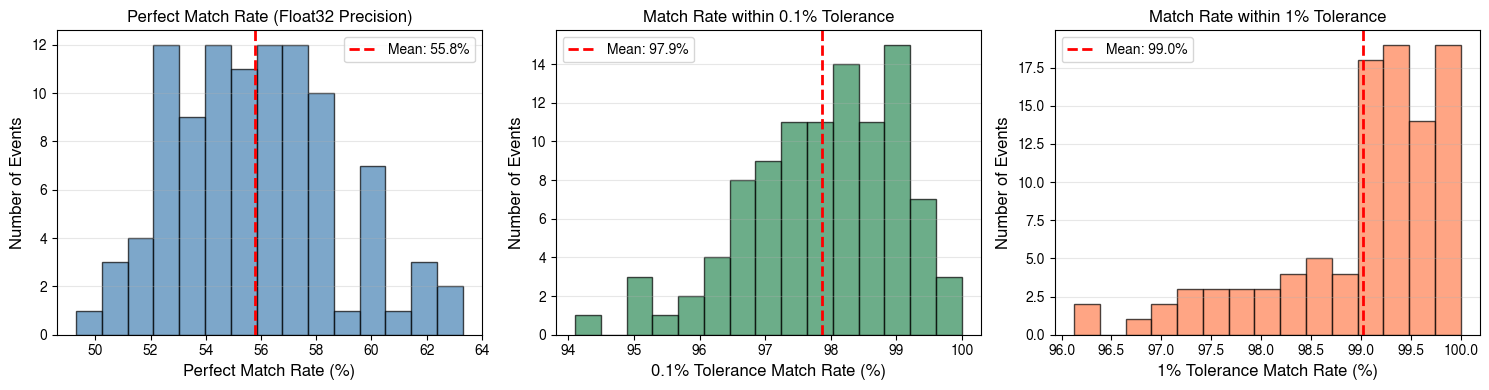

In [15]:
# Calculate match rates at different tolerances
successful_events = validation_df[validation_df['status'] == 'SUCCESS'].copy()
successful_events['perfect_match_rate'] = successful_events['num_matched_perfect'] / successful_events['num_parquet_hs_gen']
successful_events['match_0p1pct_rate'] = successful_events['num_matched_0p1pct'] / successful_events['num_parquet_hs_gen']
successful_events['match_1pct_rate'] = successful_events['num_matched_1pct'] / successful_events['num_parquet_hs_gen']

print("Match Rates at Different Tolerances:")
print(successful_events[['local_event', 'perfect_match_rate', 'match_0p1pct_rate', 'match_1pct_rate']])
print(f"\nAverage rates across all events:")
print(f"  Perfect (float32): {successful_events['perfect_match_rate'].mean()*100:.2f}%")
print(f"  0.1% tolerance: {successful_events['match_0p1pct_rate'].mean()*100:.2f}%")
print(f"  1% tolerance: {successful_events['match_1pct_rate'].mean()*100:.2f}%")

# Create histogram of match rates
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(successful_events['perfect_match_rate']*100, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Perfect Match Rate (%)', fontsize=12)
axes[0].set_ylabel('Number of Events', fontsize=12)
axes[0].set_title('Perfect Match Rate (Float32 Precision)', fontsize=12)
axes[0].axvline(successful_events['perfect_match_rate'].mean()*100, color='red', linestyle='--', linewidth=2, label=f"Mean: {successful_events['perfect_match_rate'].mean()*100:.1f}%")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(successful_events['match_0p1pct_rate']*100, bins=15, color='seagreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('0.1% Tolerance Match Rate (%)', fontsize=12)
axes[1].set_ylabel('Number of Events', fontsize=12)
axes[1].set_title('Match Rate within 0.1% Tolerance', fontsize=12)
axes[1].axvline(successful_events['match_0p1pct_rate'].mean()*100, color='red', linestyle='--', linewidth=2, label=f"Mean: {successful_events['match_0p1pct_rate'].mean()*100:.1f}%")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

axes[2].hist(successful_events['match_1pct_rate']*100, bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('1% Tolerance Match Rate (%)', fontsize=12)
axes[2].set_ylabel('Number of Events', fontsize=12)
axes[2].set_title('Match Rate within 1% Tolerance', fontsize=12)
axes[2].axvline(successful_events['match_1pct_rate'].mean()*100, color='red', linestyle='--', linewidth=2, label=f"Mean: {successful_events['match_1pct_rate'].mean()*100:.1f}%")
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# Automated Consistency Tests

Run comprehensive data consistency tests using the test suite framework. These tests validate:

1. **Particle Tests**: Completeness, parent-child relationships, vertex flags, kinematics matching
2. **Tracker Hit Tests**: Position matching, particle associations, detector encoding
3. **Track Tests**: Majority particle matching, hit validity, parameter ranges, efficiency/purity
4. **Calorimeter Tests**: Energy thresholds, position matching, contribution consistency
5. **HepMC Validation**: Hard scatter matching, vertex smearing, event number mapping
6. **Cross-Object Tests**: Consistency between particles, hits, tracks, and calo data

In [54]:
# Import the test suite
import sys
sys.path.insert(0, "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure")
from tests import run_all_tests, get_all_test_suites, get_test_summary_df, generate_test_report

ImportError: cannot import name 'get_test_summary_df' from 'tests' (/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/tests/__init__.py)

In [ ]:
# Configuration for the test run
TEST_BASE_PATH = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1"
TEST_RUN_ID = 0
TEST_LOCAL_EVENT = 0
TEST_RUN_SIZE = 128
TEST_CHUNK_SIZE = 100

print(f"Test Configuration:")
print(f"  Base Path: {TEST_BASE_PATH}")
print(f"  Run ID: {TEST_RUN_ID}")
print(f"  Local Event: {TEST_LOCAL_EVENT}")
print(f"  Global Event: {TEST_RUN_ID * TEST_RUN_SIZE + TEST_LOCAL_EVENT}")

In [ ]:
# Run all tests for a single event
results = run_all_tests(
    base_path=TEST_BASE_PATH,
    run_id=TEST_RUN_ID,
    local_event=TEST_LOCAL_EVENT,
    run_size=TEST_RUN_SIZE,
    chunk_size=TEST_CHUNK_SIZE,
    verbose=True
)

In [ ]:
# View test results as a DataFrame
test_df = get_test_summary_df(results)
test_df

In [ ]:
# Visualize test results by suite
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Group by suite and status
suite_status = test_df.groupby(['suite', 'status']).size().unstack(fill_value=0)

# Define colors for each status
colors = {'PASSED': '#2ecc71', 'FAILED': '#e74c3c', 'SKIPPED': '#95a5a6', 'ERROR': '#9b59b6'}
available_colors = [colors.get(col, '#333333') for col in suite_status.columns]

suite_status.plot(kind='barh', stacked=True, ax=ax, color=available_colors)

ax.set_xlabel('Number of Tests', fontsize=12)
ax.set_ylabel('Test Suite', fontsize=12)
ax.set_title('Test Results by Suite', fontsize=14)
ax.legend(title='Status', loc='lower right')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary:")
print(f"  Total tests: {len(test_df)}")
for status in test_df['status'].unique():
    count = (test_df['status'] == status).sum()
    print(f"  {status}: {count}")

In [ ]:
# Show failed tests with details
from tests import get_failed_tests

failed_tests = get_failed_tests(results)

if len(failed_tests) > 0:
    print(f"Failed Tests ({len(failed_tests)}):")
    print("=" * 80)
    for test in failed_tests:
        print(f"\n❌ {test.name}")
        print(f"   Message: {test.message}")
        if test.details:
            print(f"   Details:")
            for key, value in test.details.items():
                print(f"      {key}: {value}")
else:
    print("✅ All tests passed!")

## Run Tests Across Multiple Events

Optionally run tests across multiple events to check for systematic issues.

In [ ]:
# Run tests across first 10 events in the run (set RUN_MULTI_EVENT_TESTS=True to enable)
RUN_MULTI_EVENT_TESTS = False

if RUN_MULTI_EVENT_TESTS:
    from tests import run_tests_multiple_events
    
    multi_event_results = run_tests_multiple_events(
        base_path=TEST_BASE_PATH,
        run_id=TEST_RUN_ID,
        event_range=range(0, 10),
        run_size=TEST_RUN_SIZE,
        chunk_size=TEST_CHUNK_SIZE,
        verbose=False
    )
    
    print("Multi-Event Test Results:")
    print(multi_event_results[['local_event', 'passed', 'failed', 'skipped', 'errors', 'pass_rate']])
    
    # Plot pass rate across events
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(multi_event_results['local_event'], multi_event_results['pass_rate'] * 100)
    ax.set_xlabel('Local Event')
    ax.set_ylabel('Pass Rate (%)')
    ax.set_title('Test Pass Rate Across Events')
    ax.set_ylim(0, 100)
    ax.axhline(y=90, color='red', linestyle='--', label='90% threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Multi-event testing disabled. Set RUN_MULTI_EVENT_TESTS=True to enable.")

In [ ]:
# Generate and print a full test report
report = generate_test_report(results)
print(report)